# OECD FDI Income: Descriptive Statistics

This notebook produces descriptive statistics for the cleaned CSV file in the project.

The analysis follows the variable-role definitions fixed from the project reports: metadata/code fields are treated as categorical variables, `TIME_PERIOD` is treated as a discrete time variable, and `OBS_VALUE` is treated as the main continuous measurement variable.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12


C:\Users\Yusuf\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent

data_path = project_root / 'data' / 'processed' / 'OECD_FDI_Except_Pointless.csv'
df = pd.read_csv(data_path, sep=';', encoding='latin1', engine='python', on_bad_lines='skip')

# The processed file stores OBS_VALUE with dot-separated groups; removing dots restores the numeric magnitude.
df['OBS_VALUE_NUM'] = pd.to_numeric(
    df['OBS_VALUE'].astype(str).str.replace('.', '', regex=False),
    errors='coerce'
)

display(Markdown(f'**Dataset shape:** {df.shape[0]:,} rows and {df.shape[1]:,} columns'))
df.head()


**Dataset shape:** 10,344 rows and 20 columns

,REF_AREA,MEASURE,UNIT_MEASURE,MEASURE_PRINCIPLE,ACCOUNTING_ENTRY,TYPE_ENTITY,FDI_COMP,SECTOR,COUNTERPART_AREA,LEVEL_COUNTERPART,ACTIVITY,FREQ,FDI_COLLECTION_ID,TIME_PERIOD,OBS_VALUE,OBS_STATUS,UNIT_MULT,CURRENCY,DECIMALS,OBS_VALUE_NUM
0,USA,T_D4P_F,USD_EXC,DO,NET_FDI,RSP,D,S1,W,IMC,A_B,A,CTRY_IND,2024,NaN,A,6,USD,2,NaN
1,AUS,T_D4P_F,USD_EXC,DI,NET_FDI,ALL,D,S1,W,IMC,J,A,CTRY_IND,2023,19.400.704.272.141,A,6,USD,2,1.940070e+13
2,AUS,T_D4P_F,USD_EXC,DI,NET_FDI,ALL,D,S1,W,IMC,D,A,CTRY_IND,2023,20.018.603.415.055,A,6,USD,2,2.001860e+13
3,LUX,T_D4P_F,USD_EXC,DO,NET_FDI,ROU,D,S1,W,IMC,C29_30,A,CTRY_IND,2024,97.339.390.006.489,A,6,USD,2,9.733939e+13
4,AUS,T_D4P_F,USD_EXC,DO,NET_FDI,ROU,D,S1,W,IMC,J,A,CTRY_IND,2023,NaN,A,6,USD,2,NaN


## Fixed Variable-Type Schema

The descriptive analysis keeps the report-oriented variable definitions fixed instead of relying only on the storage dtype.

- Nominal categorical variables: OECD country codes, classification codes, entity codes, activity codes, status codes, and metadata fields.
- Discrete temporal variable: `TIME_PERIOD`.
- Continuous quantitative variable: `OBS_VALUE_NUM`.
- Numeric-looking metadata fields such as `UNIT_MULT` and `DECIMALS` are still treated as categorical/reporting codes, not as analytical measures.

In [3]:
variable_schema = pd.DataFrame([
    ('REF_AREA', 'Nominal categorical', 'Country / reference area code'),
    ('MEASURE', 'Nominal categorical', 'Measure code'),
    ('UNIT_MEASURE', 'Nominal categorical', 'Unit code'),
    ('MEASURE_PRINCIPLE', 'Nominal categorical', 'Directional principle code'),
    ('ACCOUNTING_ENTRY', 'Nominal categorical', 'Accounting entry code'),
    ('TYPE_ENTITY', 'Nominal categorical', 'Entity type code'),
    ('FDI_COMP', 'Nominal categorical', 'FDI component code'),
    ('SECTOR', 'Nominal categorical', 'Institutional sector code'),
    ('COUNTERPART_AREA', 'Nominal categorical', 'Counterpart area code'),
    ('LEVEL_COUNTERPART', 'Nominal categorical', 'Counterpart aggregation level'),
    ('ACTIVITY', 'Nominal categorical', 'Economic activity code'),
    ('FREQ', 'Nominal categorical', 'Frequency code'),
    ('FDI_COLLECTION_ID', 'Nominal categorical', 'Collection identifier'),
    ('TIME_PERIOD', 'Discrete temporal', 'Reference year'),
    ('OBS_VALUE', 'Source text field', 'Original raw numeric string'),
    ('OBS_VALUE_NUM', 'Continuous quantitative', 'Cleaned FDI income value'),
    ('OBS_STATUS', 'Nominal categorical', 'Observation status code'),
    ('UNIT_MULT', 'Nominal categorical', 'Scale code, kept categorical by definition'),
    ('CURRENCY', 'Nominal categorical', 'Currency code'),
    ('DECIMALS', 'Nominal categorical', 'Display precision code, kept categorical by definition'),
], columns=['Variable', 'Type used in analysis', 'Reason'])
display(variable_schema)


,Variable,Type used in analysis,Reason
0,REF_AREA,Nominal categorical,Country / reference area code
1,MEASURE,Nominal categorical,Measure code
2,UNIT_MEASURE,Nominal categorical,Unit code
3,MEASURE_PRINCIPLE,Nominal categorical,Directional principle code
4,ACCOUNTING_ENTRY,Nominal categorical,Accounting entry code
5,TYPE_ENTITY,Nominal categorical,Entity type code
6,FDI_COMP,Nominal categorical,FDI component code
7,SECTOR,Nominal categorical,Institutional sector code
8,COUNTERPART_AREA,Nominal categorical,Counterpart area code
9,LEVEL_COUNTERPART,Nominal categorical,Counterpart aggregation level


In [4]:
overview = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique(dropna=False),
    'stored_dtype': df.dtypes.astype(str),
}).sort_values(['missing_pct', 'unique_values'], ascending=[False, False])
display(overview)


,missing_count,missing_pct,unique_values,stored_dtype
OBS_VALUE_NUM,2937,28.39,2799,float64
OBS_VALUE,2901,28.05,2825,str
REF_AREA,0,0.00,38,str
ACTIVITY,0,0.00,27,str
TYPE_ENTITY,0,0.00,3,str
MEASURE_PRINCIPLE,0,0.00,2,str
TIME_PERIOD,0,0.00,2,int64
MEASURE,0,0.00,1,str
UNIT_MEASURE,0,0.00,1,str
ACCOUNTING_ENTRY,0,0.00,1,str


### Comment

Most variables are metadata or classification fields with very low variability. This confirms that the dataset is structurally standardized and that the main analytical variation is concentrated in `REF_AREA`, `ACTIVITY`, `TIME_PERIOD`, `TYPE_ENTITY`, `MEASURE_PRINCIPLE`, and especially `OBS_VALUE_NUM`.

In [5]:
constant_variables = [col for col in df.columns if df[col].nunique(dropna=False) == 1]
display(Markdown('**Constant metadata variables:** ' + ', '.join(constant_variables)))

selected_categorical = ['REF_AREA', 'ACTIVITY', 'TYPE_ENTITY', 'MEASURE_PRINCIPLE', 'TIME_PERIOD']
categorical_summary = pd.concat(
    [
        df[col].value_counts(dropna=False).head(10).rename_axis('category').reset_index(name='count').assign(variable=col)
        for col in selected_categorical
    ],
    ignore_index=True
)
display(categorical_summary)


**Constant metadata variables:** MEASURE, UNIT_MEASURE, ACCOUNTING_ENTRY, FDI_COMP, SECTOR, COUNTERPART_AREA, LEVEL_COUNTERPART, FREQ, FDI_COLLECTION_ID, OBS_STATUS, UNIT_MULT, CURRENCY, DECIMALS

,category,count,variable
0,USA,324,REF_AREA
1,AUS,324,REF_AREA
2,LUX,324,REF_AREA
3,GRC,324,REF_AREA
4,AUT,324,REF_AREA
5,BEL,324,REF_AREA
6,CZE,324,REF_AREA
7,DNK,324,REF_AREA
8,EST,324,REF_AREA
9,FIN,324,REF_AREA


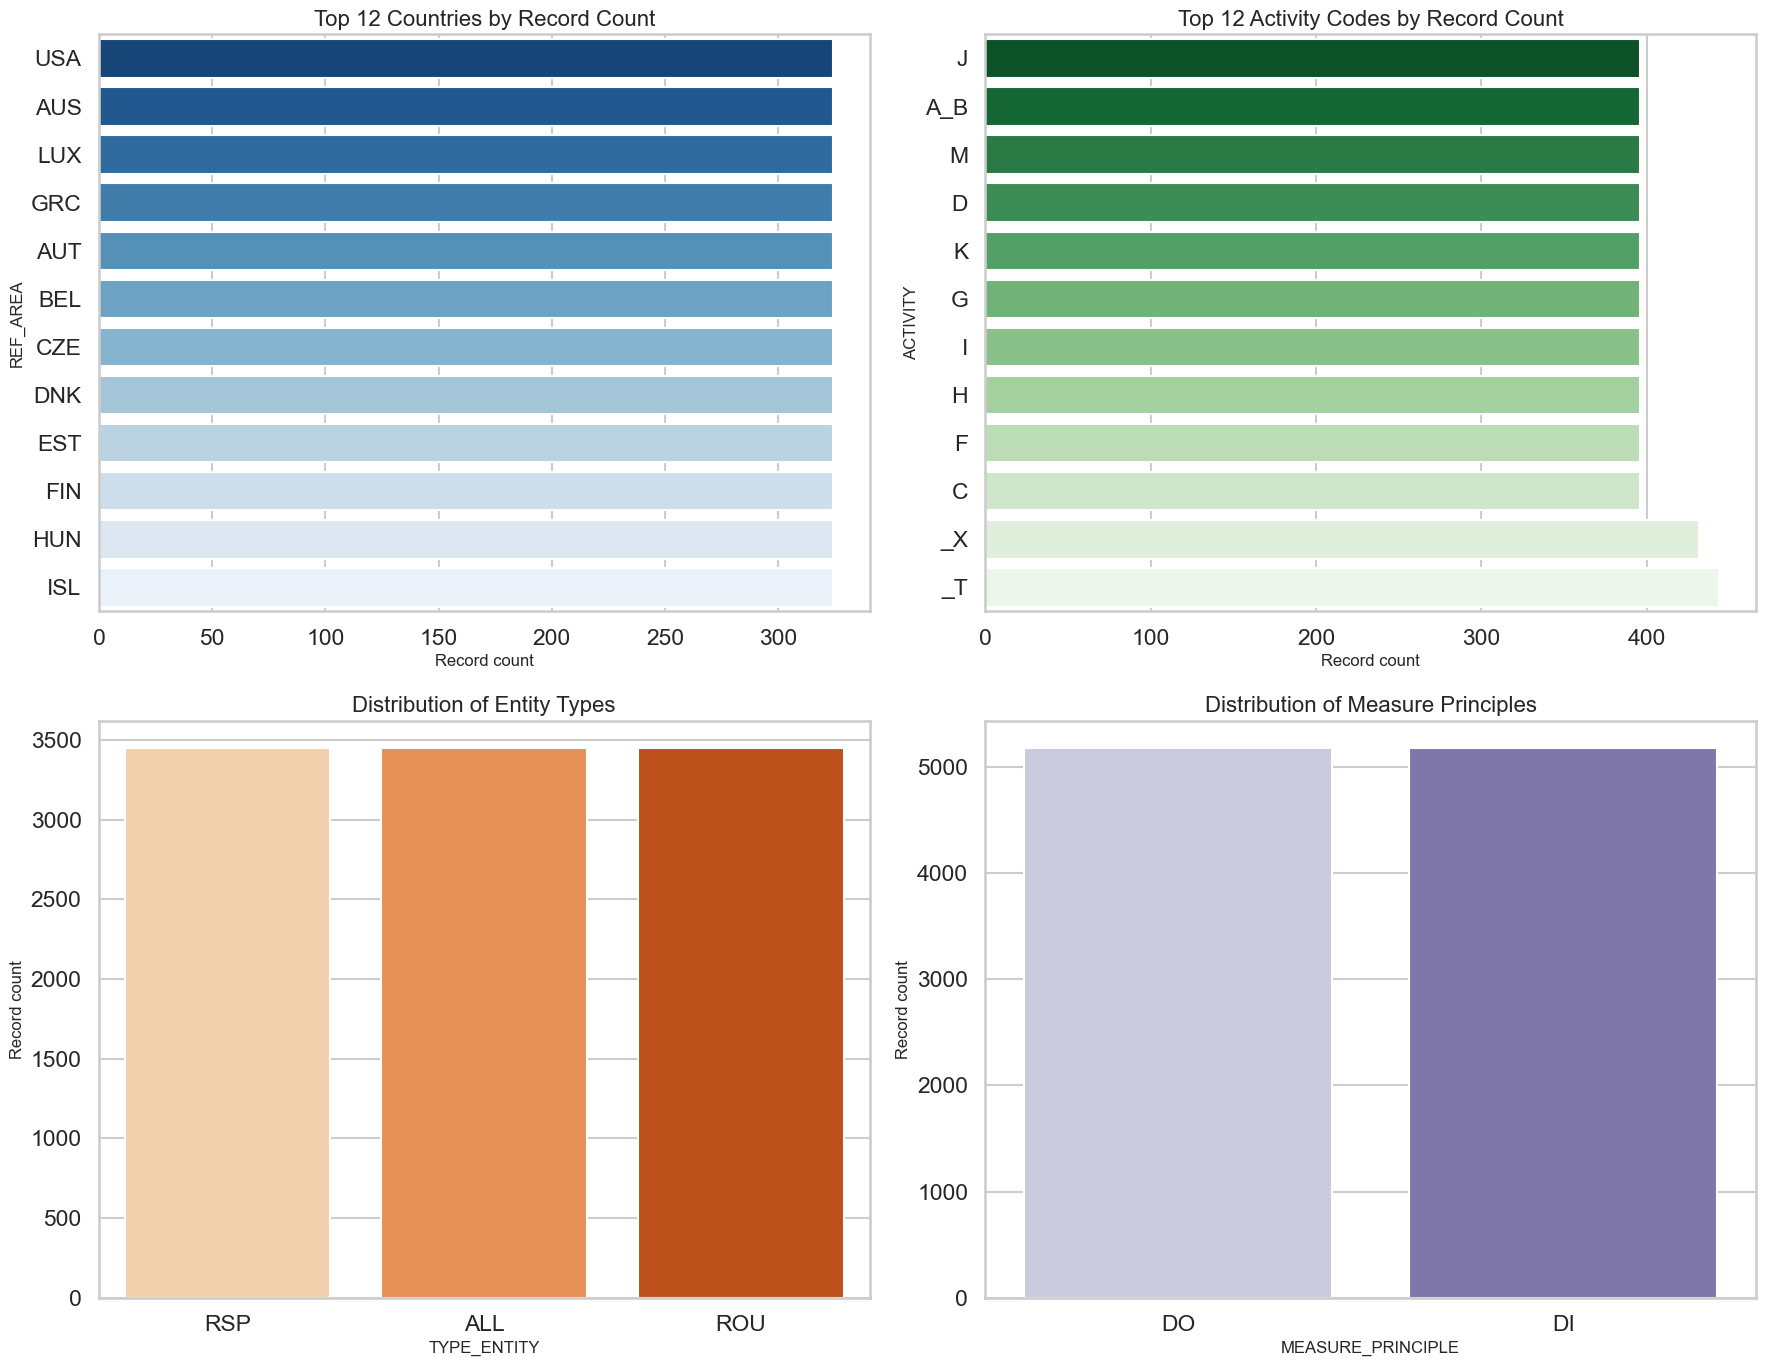

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

top_ref_area = df['REF_AREA'].value_counts().head(12).sort_values()
sns.barplot(x=top_ref_area.values, y=top_ref_area.index, ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Top 12 Countries by Record Count')
axes[0, 0].set_xlabel('Record count')
axes[0, 0].set_ylabel('REF_AREA')

top_activity = df['ACTIVITY'].value_counts().head(12).sort_values()
sns.barplot(x=top_activity.values, y=top_activity.index, ax=axes[0, 1], palette='Greens_r')
axes[0, 1].set_title('Top 12 Activity Codes by Record Count')
axes[0, 1].set_xlabel('Record count')
axes[0, 1].set_ylabel('ACTIVITY')

type_entity_counts = df['TYPE_ENTITY'].value_counts().sort_values(ascending=False)
sns.barplot(x=type_entity_counts.index, y=type_entity_counts.values, ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_title('Distribution of Entity Types')
axes[1, 0].set_xlabel('TYPE_ENTITY')
axes[1, 0].set_ylabel('Record count')

measure_principle_counts = df['MEASURE_PRINCIPLE'].value_counts().sort_values(ascending=False)
sns.barplot(x=measure_principle_counts.index, y=measure_principle_counts.values, ax=axes[1, 1], palette='Purples')
axes[1, 1].set_title('Distribution of Measure Principles')
axes[1, 1].set_xlabel('MEASURE_PRINCIPLE')
axes[1, 1].set_ylabel('Record count')

plt.tight_layout()
plt.show()


### Comment

The dataset is highly balanced across several design dimensions. `TYPE_ENTITY` is perfectly split across the three entity categories, and `MEASURE_PRINCIPLE` is evenly divided between the two directional principles. Country counts are also uniform among the leading countries shown here, which suggests that the file was assembled from a regular reporting grid rather than from opportunistic sampling.

,TIME_PERIOD,count
0,2023,5508
1,2024,4836


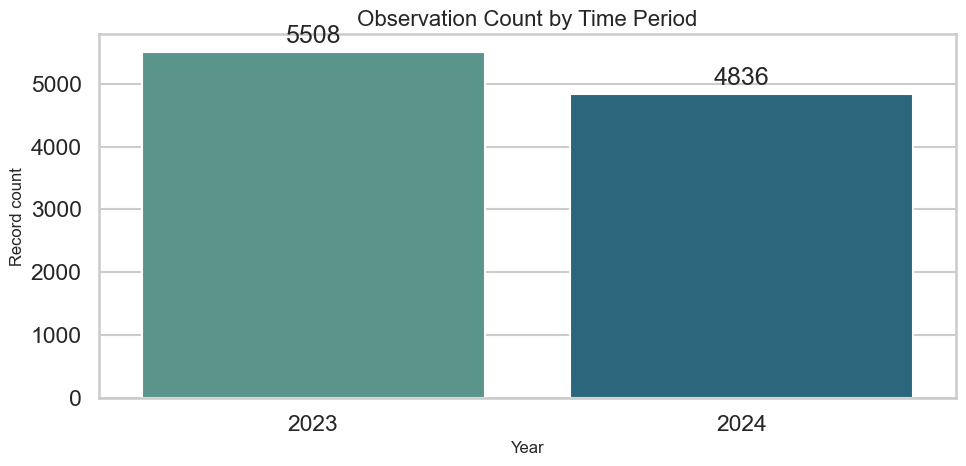

In [7]:
time_summary = df['TIME_PERIOD'].value_counts().sort_index().rename_axis('TIME_PERIOD').reset_index(name='count')
display(time_summary)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=time_summary, x='TIME_PERIOD', y='count', palette='crest')
ax.set_title('Observation Count by Time Period')
ax.set_xlabel('Year')
ax.set_ylabel('Record count')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.tight_layout()
plt.show()


### Comment

The cleaned dataset covers two years only: 2023 and 2024. The number of observations is slightly higher in 2023 than in 2024, so simple count-based comparisons across years should be interpreted with that small imbalance in mind.

In [8]:
obs_stats = df['OBS_VALUE_NUM'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('OBS_VALUE_NUM')
obs_stats.loc['skewness'] = df['OBS_VALUE_NUM'].skew()
obs_stats.loc['kurtosis'] = df['OBS_VALUE_NUM'].kurtosis()
display(obs_stats)

year_stats = df.groupby('TIME_PERIOD')['OBS_VALUE_NUM'].describe(percentiles=[0.25, 0.5, 0.75])
display(year_stats)


,OBS_VALUE_NUM
count,7.407000e+03
mean,1.590132e+13
std,2.791554e+13
min,-9.593532e+13
1%,-5.075893e+13
5%,-1.297578e+12
25%,0.000000e+00
50%,9.114000e+07
75%,2.650251e+13
95%,7.649538e+13


,count,mean,std,min,25%,50%,75%,max
TIME_PERIOD,,,,,,,,
2023,3915.0,1.633646e+13,2.756233e+13,-9.593532e+13,0.0,1.382563e+12,2.682940e+13,9.984813e+13
2024,3492.0,1.541346e+13,2.830229e+13,-9.437035e+13,0.0,3.089426e+07,2.609503e+13,9.968215e+13


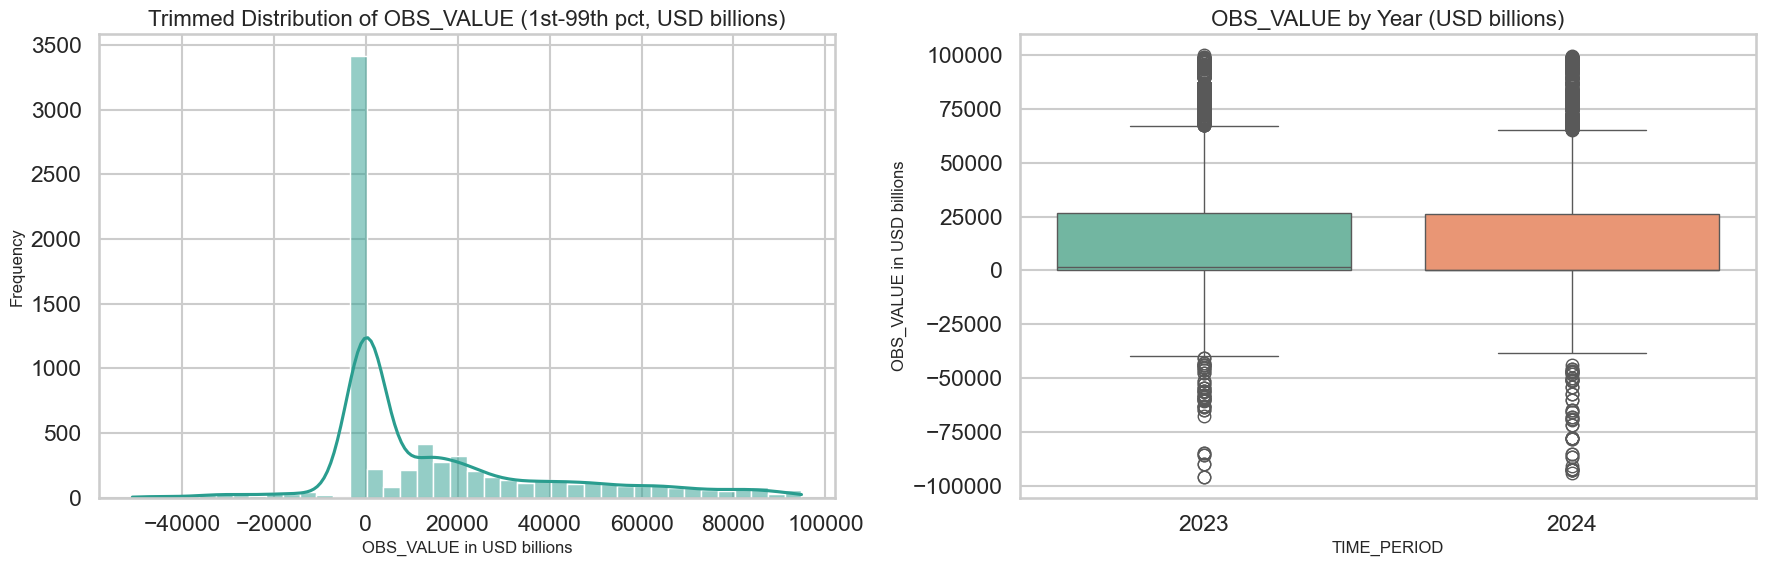

In [9]:
plot_df = df[['OBS_VALUE_NUM', 'TIME_PERIOD']].dropna().copy()
plot_df['OBS_VALUE_BILLION'] = plot_df['OBS_VALUE_NUM'] / 1e9
clip_low, clip_high = plot_df['OBS_VALUE_BILLION'].quantile([0.01, 0.99])
trimmed = plot_df[plot_df['OBS_VALUE_BILLION'].between(clip_low, clip_high)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(trimmed['OBS_VALUE_BILLION'], bins=40, kde=True, color='#2a9d8f', ax=axes[0])
axes[0].set_title('Trimmed Distribution of OBS_VALUE (1st-99th pct, USD billions)')
axes[0].set_xlabel('OBS_VALUE in USD billions')
axes[0].set_ylabel('Frequency')

sns.boxplot(data=plot_df, x='TIME_PERIOD', y='OBS_VALUE_BILLION', palette='Set2', ax=axes[1])
axes[1].set_title('OBS_VALUE by Year (USD billions)')
axes[1].set_xlabel('TIME_PERIOD')
axes[1].set_ylabel('OBS_VALUE in USD billions')

plt.tight_layout()
plt.show()


In [10]:
missing_obs_by_year = (
    df.assign(is_missing_obs=df['OBS_VALUE_NUM'].isna())
      .groupby('TIME_PERIOD')['is_missing_obs']
      .agg(['sum', 'mean'])
      .rename(columns={'sum': 'missing_count', 'mean': 'missing_ratio'})
)
missing_obs_by_year['missing_ratio'] = (missing_obs_by_year['missing_ratio'] * 100).round(2)
display(missing_obs_by_year)


,missing_count,missing_ratio
TIME_PERIOD,,
2023,1593,28.92
2024,1344,27.79


### Comment

`OBS_VALUE_NUM` is highly dispersed and strongly right-skewed, with very large positive values but also substantial negative values. The median is far below the mean, which indicates that the average is heavily influenced by extreme observations. Missingness is also meaningful: almost three thousand records do not contain a usable numerical observation, so any downstream modeling step should explicitly decide how to handle those missing values.

## Overall Interpretation

This descriptive profile shows a dataset that is structurally regular but numerically volatile.

- The metadata side is extremely standardized, with many fields fixed to a single OECD code.
- The design dimensions that actually vary are country, activity, entity type, measure principle, year, and the observed FDI income value.
- `OBS_VALUE_NUM` has a wide spread, a long right tail, and non-trivial missingness, so robust statistics and visual trimming are more informative than relying on the mean alone.
- Because `TIME_PERIOD` only spans 2023-2024, this notebook provides a cross-sectional descriptive view rather than a long-run time-series profile.